# 24 - Clinical Feature Analysis on Independent Dataset (Normalised)

Test the 17 clinical imaging features (ARFI elastography and DCE-US perfusion) on the
independent dataset of 55 studies (one study per patient), rather than on all 138 studies.

**Why:** The full-dataset clinical analysis (NB 14b) reproduces Bassaganyas et al. and uses
all studies, which violates the independence assumption because many patients contribute
several studies. This notebook restricts the analysis to one study per patient so that every
observation is independent, answering whether the clinical biomarkers still discriminate
rejection when repeated measures are removed.

**Method (same tests as NB 14b):**
- Mann-Whitney U test, rejection vs no rejection, per feature.
- Effect size: rank-biserial correlation.
- Benjamini-Hochberg FDR correction is added as an extra column for completeness. The
  uncorrected p-value remains the headline, matching the full-dataset clinical table.

The 55 study identifiers come from the independent dataset built in NB 18. The clinical
measurements come directly from the source spreadsheet.

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


In [2]:
# load the independent dataset (built in NB 18) and take its 55 study ids
independent = pd.read_csv(os.path.join("reports", "18_independent_dataset_normalised.csv"))
independent_ids = independent["study_id"].astype(str).str.strip().tolist()
print(f"Independent dataset: {len(independent_ids)} studies (one per patient)")

# load clinical measurements from source and rename key columns (as in NB 14b)
clinical = pd.read_csv(os.path.join("..", "data", "bd_estudiUPF.csv"))
clinical["id estudio"] = clinical["id estudio"].astype(str).str.strip()
clinical = clinical.rename(columns={
    "id estudio": "study_id",
    "RECHAZO CLÍNICO": "rejection",
})

# keep only the independent studies
clinical_indep = clinical[clinical["study_id"].isin(independent_ids)].copy()
print(f"Matched clinical rows: {len(clinical_indep)} / {len(independent_ids)}")
print(f"No rejection: {(clinical_indep['rejection'] == 0).sum()}, "
      f"Rejection: {(clinical_indep['rejection'] == 1).sum()}")

Independent dataset: 55 studies (one per patient)
Matched clinical rows: 55 / 55
No rejection: 34, Rejection: 21


## Clinical features tested

The same 17 features as the full-dataset analysis: 4 ARFI, 11 DCE-US, and 2 quality/area
parameters. Not every study has every measurement, so sample sizes are reported per feature
after dropping missing values.

In [3]:
arfi_features = ["ARFI mediana", "ARFI media", "ARFI DE", "ARFI RIQ"]
dceus_features = ["PE", "WiAUC", "RT", "mTTI", "TTP", "WiR", "WiPi",
                  "WoAUC", "WiWoAUC", "FT", "WoR"]
other_features = ["QOF", "Area"]
all_clinical_features = arfi_features + dceus_features + other_features

print("Feature availability among the 55 independent studies:")
for feat in all_clinical_features:
    n_valid = clinical_indep[feat].dropna().shape[0]
    print(f"  {feat}: {n_valid} non-null")

Feature availability among the 55 independent studies:
  ARFI mediana: 47 non-null
  ARFI media: 47 non-null
  ARFI DE: 47 non-null
  ARFI RIQ: 47 non-null
  PE: 54 non-null
  WiAUC: 54 non-null
  RT: 54 non-null
  mTTI: 54 non-null
  TTP: 54 non-null
  WiR: 54 non-null
  WiPi: 54 non-null
  WoAUC: 54 non-null
  WiWoAUC: 54 non-null
  FT: 54 non-null
  WoR: 54 non-null
  QOF: 54 non-null
  Area: 54 non-null


In [4]:
rejection = clinical_indep[clinical_indep["rejection"] == 1]
no_rejection = clinical_indep[clinical_indep["rejection"] == 0]

test_results = []
for feat in all_clinical_features:
    vals_no_rej = no_rejection[feat].dropna().values
    vals_rej = rejection[feat].dropna().values

    if len(vals_no_rej) < 3 or len(vals_rej) < 3:
        print(f"  Skipping {feat}: too few values")
        continue

    stat, p_value = stats.mannwhitneyu(vals_no_rej, vals_rej, alternative="two-sided")
    n1 = len(vals_no_rej)
    n2 = len(vals_rej)
    effect_size = 1 - (2 * stat) / (n1 * n2)

    test_results.append({
        "feature": feat,
        "n_no_rej": n1,
        "n_rej": n2,
        "p_value": p_value,
        "effect_size": effect_size,
        "median_no_rej": np.median(vals_no_rej),
        "median_rej": np.median(vals_rej),
    })

results_df = pd.DataFrame(test_results).sort_values("p_value").reset_index(drop=True)
print(f"Features tested: {len(results_df)}")

Features tested: 17


In [5]:
# add Benjamini-Hochberg FDR correction as an extra column
reject_fdr, pvals_fdr, _, _ = multipletests(
    results_df["p_value"].values, alpha=0.05, method="fdr_bh")
results_df["p_value_fdr"] = pvals_fdr
results_df["significant_fdr"] = reject_fdr

n_uncorrected = (results_df["p_value"] < 0.05).sum()
n_fdr = results_df["significant_fdr"].sum()
print(f"Uncorrected p < 0.05: {n_uncorrected} / {len(results_df)}")
print(f"FDR-corrected p < 0.05: {n_fdr} / {len(results_df)}")
print()

show_cols = ["feature", "n_no_rej", "n_rej", "p_value", "p_value_fdr",
             "effect_size", "median_no_rej", "median_rej"]
print(results_df[show_cols].to_string(index=False))

Uncorrected p < 0.05: 0 / 17
FDR-corrected p < 0.05: 0 / 17

     feature  n_no_rej  n_rej  p_value  p_value_fdr  effect_size  median_no_rej  median_rej
          RT        34     20 0.059984     0.362509     0.310294          5.015       6.230
          FT        34     20 0.104995     0.362509     0.267647          9.485      11.515
         WiR        34     20 0.108899     0.362509    -0.264706        327.630     193.745
         WoR        34     20 0.112909     0.362509    -0.261765        140.620      80.995
         TTP        34     20 0.125599     0.362509     0.252941          8.380       9.210
        Area        34     20 0.145641     0.362509    -0.238235          0.485       0.460
        WiPi        34     20 0.165072     0.362509    -0.229412        667.045     482.045
          PE        34     20 0.170593     0.362509    -0.226471       1033.125     756.440
         QOF        34     20 0.384982     0.663246     0.144118         89.885      89.210
     WiWoAUC       

## Box plots of the four ARFI features

The ARFI features carry the positive signal in the full-dataset late-period analysis. These
box plots show their distributions on the independent dataset (pooled across time periods),
where the distributions overlap and none of the features reaches significance.

/tmp/ipykernel_12562/998925901.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
/tmp/ipykernel_12562/998925901.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
/tmp/ipykernel_12562/998925901.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
/tmp/ipykernel_12562/998925901.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

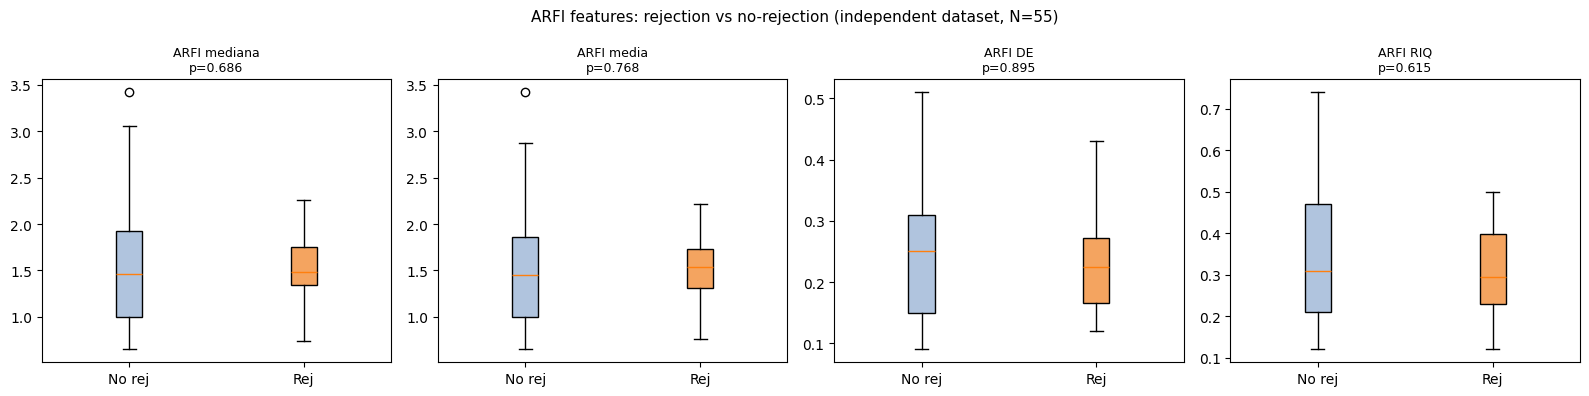

Saved to reports/24_boxplots_clinical_independent.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(arfi_features):
    data_no = no_rejection[feat].dropna().values
    data_rej = rejection[feat].dropna().values
    bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#B0C4DE")
    bp["boxes"][1].set_facecolor("#F4A460")
    p_val = results_df[results_df["feature"] == feat]["p_value"].values[0]
    axes[i].set_title(f"{feat}\np={p_val:.3f}", fontsize=9)

plt.suptitle("ARFI features: rejection vs no-rejection (independent dataset, N=55)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join("reports", "24_boxplots_clinical_independent.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/24_boxplots_clinical_independent.png")

In [7]:
output_path = os.path.join("reports", "24_clinical_stats_independent.csv")
results_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print()
print("SUMMARY")
print(f"Independent studies: {len(clinical_indep)} (one per patient)")
print(f"Clinical features tested: {len(results_df)}")
print(f"Uncorrected p < 0.05: {(results_df['p_value'] < 0.05).sum()}")
print(f"FDR-corrected p < 0.05: {results_df['significant_fdr'].sum()}")

Saved to reports/24_clinical_stats_independent.csv

SUMMARY
Independent studies: 55 (one per patient)
Clinical features tested: 17
Uncorrected p < 0.05: 0
FDR-corrected p < 0.05: 0


## Interpretation

On the independent dataset (one study per patient, pooled across all post-transplant time
periods), **no clinical feature reaches significance**, not even uncorrected. ARFI mediana
(p = 0.69) and ARFI media (p = 0.77) are far from significant, in contrast to the full dataset
(ARFI mediana p = 0.028) and especially the late post-transplant subset (ARFI p < 0.001).

This is consistent with the rest of the thesis rather than contradicting it. The ARFI signal
is specific to the **late** post-transplant period. The independent dataset selects one study
per patient, preferring the first rejection study for patients who experienced rejection; many
of these fall in the early period, where ARFI does not discriminate. Pooling early and late
studies therefore dilutes the ARFI effect. This mirrors the paired analysis (NB 21), where the
within-patient ARFI difference also vanished, and supports the interpretation that ARFI
reflects between-patient and time-dependent tissue stiffness rather than an acute, uniformly
detectable rejection signal.

The independent late-period subset is too small for a separate clinical test (see NB 25: only
13 studies fall beyond 90 days), so the pooled result is reported here with this timing caveat.